In [1]:


import jax 
import jax.numpy as jnp
import jax.random as jrandom


import haiku as hk
import optax

import matplotlib.pyplot as plt

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

from probjax.utils.sdeint import sdeint
from probjax.utils.odeint import _odeint
from probjax.utils.graph import min_faithfull_mask

from functools import partial



In [2]:
cpu = jax.devices("cpu")[0]
jax.devices()

[cuda(id=0),
 cuda(id=1),
 cuda(id=2),
 cuda(id=3),
 cuda(id=4),
 cuda(id=5),
 cuda(id=6),
 cuda(id=7)]

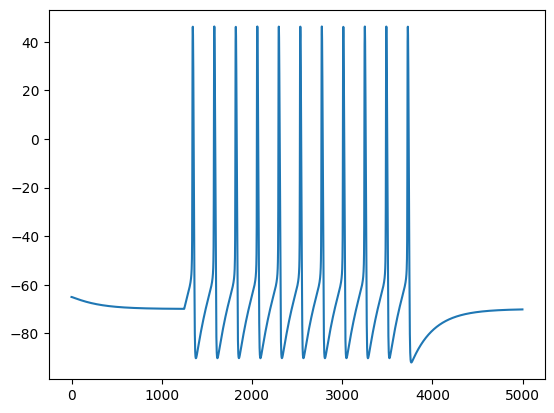

In [3]:
ts = jnp.linspace(0, 3, 100)


V0 = -65.0  # Initial membrane voltage (mV)


def I_inj_fn(t, t_val, Vt_val):
    index = jnp.searchsorted(t_val, t, side='right') - 1
    return jax.lax.cond(index < 0, lambda _: 0.0, lambda _: Vt_val[index], None)

def efun(x):
    return jnp.where(x < 1e-4, 1-x /2, x/(jnp.exp(x) - 1.0))

def alpha_m_fn(V):
    return 0.32 * efun(-0.25*(V - V0 - 13.0)) / 0.25

def beta_m_fn(V):
    return 0.28 * efun(0.2*(V - V0 - 40.0)) / 0.2

def alpha_h_fn(V):
    return 0.128 * jnp.exp(-(V - V0 - 17.0) / 18.0)

def beta_h_fn(V):
    return 4.0 / (1.0 + jnp.exp(-(V - V0 - 40.0) / 5.0))

def alpha_n_fn(V):
    return 0.032 * efun(-0.2*(V - V0 - 15.0)) / 0.2

def beta_n_fn(V):
    return 0.5 * jnp.exp(-(V - V0 - 10.0) / 40.0)

def hodgkin_huxley(t, state, Cm, g_Na, g_K, g_L, E_Na, E_K, E_L, t_val,Vt_val):
    V, m, h, n, H = state

    # Membrane capacitance (uF/cm^2)
    # Sodium conductance (mS/cm^2)
    # Potassium conductance (mS/cm^2)
    # Leak conductance (mS/cm^2)
    # Sodium reversal potential (mV)
    # Potassium reversal potential (mV)
    # Leak reversal potential (mV)

    # Alpha and beta functions for m, h, and n
    alpha_n = alpha_n_fn(V)
    beta_n = beta_n_fn(V)
    alpha_m = alpha_m_fn(V)
    beta_m = beta_m_fn(V)
    alpha_h = alpha_h_fn(V)
    beta_h = beta_h_fn(V)
    
    i_Na = g_Na * m**3 * h * (V - E_Na)
    i_K = g_K * n**4 * (V - E_K)
    i_L = g_L * (V - E_L)
    # Hodgkin-Huxley ODEs
    dV = (I_inj_fn(t, t_val, Vt_val) - i_Na - i_K - i_L) / Cm
    dm = alpha_m * (1.0 - m) - beta_m * m
    dh = alpha_h * (1.0 - h) - beta_h * h
    dn = alpha_n * (1.0 - n) - beta_n * n
    dH = (V*I_inj_fn(t, t_val, Vt_val) - i_Na * (V - E_Na) - i_K * (V - E_K) - i_L * (V - E_L)) / 10**6 # in mJ

    return dV, dm, dh, dn, dH

t_min = 0.0
t_max = 200.

params = (1.0, 100.0, 40.0, 0.1, 53.0, -107.0, -70)
t_val = jnp.array([50., 150])
Vt_val = jnp.array([4., 0])

ts_dense = jnp.linspace(t_min, t_max, 5000)
m0 = alpha_n_fn(V0) / (alpha_n_fn(V0) + beta_n_fn(V0))
h0 = alpha_h_fn(V0) / (alpha_h_fn(V0) + beta_h_fn(V0))
n0 = alpha_m_fn(V0) / (alpha_m_fn(V0) + beta_m_fn(V0))
H0 = jnp.zeros_like(V0)
V, _,_,_, H = _odeint(hodgkin_huxley, (V0, m0, h0, n0, H0), ts_dense, *params, t_val, Vt_val, method="ssprk3")

plt.plot(V)

In [4]:

def compute_summary_statistics(V, ts_dense, t_val):
    V_mod = jnp.where(V < -10, -10, V)
    V_mod = jnp.where(jnp.diff(V, prepend=jnp.array([-10.])) < 0, -10, V_mod)

    spike_occured = jnp.where(jnp.diff(V_mod, prepend=jnp.array([-10.])) < 0, 1., 0.)
    spike_count = jnp.sum(spike_occured, keepdims=True)

    # Resting potential
    V_rest = jnp.where(ts_dense < t_val[0], V, jnp.nan)
    V_rest_mean = jnp.nanmean(V_rest, keepdims=True)
    V_rest_std = jnp.nanstd(V_rest, keepdims=True)

    # Spiking domain mean 
    V_spike = jnp.where((ts_dense > t_val[0]) & (ts_dense < t_val[-1]), V, jnp.nan)    
    V_spike_mean = jnp.nanmean(V_spike)
    # Moments 
    n_mom = 4
    input_voltage_mask = (ts_dense > t_val[0]) & (ts_dense < t_val[-1])
    V_input = jnp.where(input_voltage_mask, V, jnp.nan)
    std_input_voltage = jnp.nanstd(V_input)
    std_pw = jnp.power(std_input_voltage, jnp.linspace(3, n_mom, n_mom - 2))
    std_pw = jnp.concatenate((jnp.ones(1), std_pw))

    moments = jnp.linspace(2, n_mom, n_mom - 1)
    V_input_mean = jnp.nanmean(V_input)
    V_input_pw = V_input - V_input_mean
    V_input_pw = jnp.power(V_input_pw[...,None], moments)
    V_input_moments = jnp.nanmean(V_input_pw, axis=0)
    V_input_moments = V_input_moments / std_pw

    return spike_count, V_rest_mean, V_rest_std, V_spike_mean[...,None], *jnp.split(V_input_moments, n_mom - 1, axis=-1)

In [5]:
@jax.vmap
def generate_dense_data(key):
    key1, key2, key3, key4, key5, key6, key7 = jrandom.split(key, 7) 
    Cm = jax.random.uniform(key1, (1,), minval=1., maxval=2.)
    g_Na = jax.random.uniform(key2, (1,), minval=60, maxval=120)
    g_K = jax.random.uniform(key3, (1,), minval=10, maxval=30)
    g_L = jax.random.uniform(key4, (1,), minval=0.1, maxval=0.5)
    E_Na = jax.random.uniform(key5, (1,), minval=40, maxval=70)
    E_K = jax.random.uniform(key6, (1,), minval=-100, maxval=-60)
    E_V = jax.random.uniform(key7, (1,), minval=-90, maxval=-60)
    params = (Cm, g_Na, g_K, g_L, E_Na, E_K, E_V)
    V, _,_,_, H = _odeint(hodgkin_huxley, (V0, m0, h0, n0, H0), ts_dense, *params, t_val, Vt_val, method="ssprk3")
    V = jnp.nan_to_num(V, nan=V0, posinf=V0, neginf=V0)
    V = jnp.clip(V, -100, 100)
    summary_stats = compute_summary_statistics(V, ts_dense, t_val)
    total_energy = H[-1][...,None]
    data = jnp.concatenate(params + (V,) +(total_energy,)+ summary_stats, axis=-1)
    return data
    

In [6]:
dataset = []
for i in range(20):
    samples = generate_dense_data(jax.random.split(jax.random.PRNGKey(i), (5000,)))
    samples = jax.device_put(samples, cpu)
    dataset.append(samples)
    del samples

In [7]:
with jax.default_device(cpu):
    dataset = jnp.concatenate(dataset, axis=0)
    dataset = jax.device_put(dataset, cpu)  

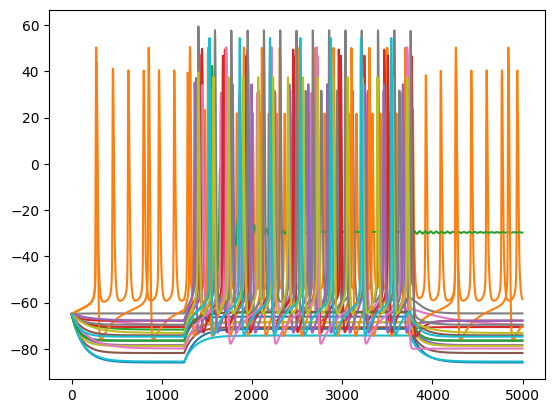

In [8]:
_ = plt.plot(dataset[:20,7:-8].T)

In [9]:
with jax.default_device(cpu):
    num_timeponts = 345
    @partial(jax.jit, static_argnums=(1,))
    def subsample_data(key, batch_size, dataset):
        key_batch, key_t1, key_t2, key_t3, key_noise = jrandom.split(key, 5)
        index = jax.random.randint(key_batch, (batch_size,), 0, len(dataset))
        data = dataset[index]
        thetas, V, energy, summary_stats = jnp.split(data, (7, 7 +len(ts_dense), 7 +len(ts_dense) + 1, ), axis=-1)
        sub_interval_size = jax.random.choice(key_t3, jnp.array([50.,100., 200.]), shape=(batch_size, 1))
        t_start = jax.random.uniform(key_t1, (batch_size, 1),minval=t_min, maxval = t_max - sub_interval_size)
        t_sub = t_start + jnp.arange(num_timeponts)[None, :] * sub_interval_size / num_timeponts

        V_sub = jax.vmap(jnp.interp, in_axes=(0,None, 0))(t_sub, ts_dense, V)
        V_noised = V_sub + jax.random.normal(key_noise, V_sub.shape) *0.2
        
        data = jnp.concatenate((thetas, V_noised, energy, summary_stats), axis=-1).reshape(batch_size, -1, 1)
        nodes_ids = jnp.array([0, 1, 2, 3, 4, 5, 6] + [7]*num_timeponts + [8] + [9,10,11,12,13,14,15]).reshape(1, -1, 1)
        meta_data = jnp.concatenate((jnp.full((batch_size, 7), jnp.nan), t_sub, jnp.full((batch_size, 8), jnp.nan)), axis=-1).reshape(batch_size, -1, 1)
        return data, nodes_ids, meta_data
        

    sampler = partial(subsample_data, dataset=dataset)

In [10]:
with jax.default_device(cpu):
    data, nodes_ids, meta_data = sampler(jrandom.PRNGKey(0), 1000)
    print(data.shape, nodes_ids.shape, meta_data.shape)

(1000, 360, 1) (1, 360, 1) (1000, 360, 1)


In [11]:
def base_mask_fn(node_ids, meta_data):
    # Assumes meta_data is sorted
    num_time_points = jnp.sum(node_ids == 7)
    #meta_data_time_points = meta_data[:, 8:]
    #index_sorted = jnp.argsort(meta_data_time_points)
    theta_mask = jnp.eye(7, dtype=jnp.bool_)
    summary_mask = jnp.eye(7, dtype=jnp.bool_)
    energy_mask = jnp.eye(1, dtype=jnp.bool_)   

    xs_mask = jnp.eye(num_time_points, dtype=jnp.bool_) | jnp.eye(num_time_points, k=-1, dtype=jnp.bool_)
    mask_theta_x = jnp.ones((num_time_points, 7), dtype=jnp.bool_)
    mask_theta_energy = jnp.ones((1,7), dtype=jnp.bool_)
    mask_x_energy = jnp.zeros((1, num_time_points), dtype=jnp.bool_)
    mask_x_summary = jnp.zeros((7,num_time_points), dtype=jnp.bool_)
    mask_theta_summary = jnp.ones((7,7), dtype=jnp.bool_)
    mask_fill = jnp.zeros((7,num_time_points), dtype=jnp.bool_)
    mask_fill2 = jnp.zeros((7, 7), dtype=jnp.bool_)
    mask_fill3 = jnp.zeros((7, 1), dtype=jnp.bool_)
    mask_fill4 = jnp.zeros((num_time_points, 7), dtype=jnp.bool_)
    mask_fill5 = jnp.zeros((num_time_points, 1), dtype=jnp.bool_)
    mask_fill6 = jnp.zeros((1, num_time_points), dtype=jnp.bool_)
    
    row1 = jnp.concatenate((theta_mask, mask_fill, mask_fill2, mask_fill3), axis=1)
    row2 = jnp.concatenate((mask_theta_x, xs_mask, mask_fill4, mask_fill5), axis=1)
    row3 = jnp.concatenate((mask_theta_energy, mask_x_energy, energy_mask, mask_fill3.T), axis=1)
    row4 = jnp.concatenate((mask_theta_summary, mask_x_summary, mask_fill3, summary_mask), axis=1)
    
    base_mask = jnp.concatenate((row1, row2, row3, row4), axis=0)
    
    # Summary statistics
    
    
    return base_mask

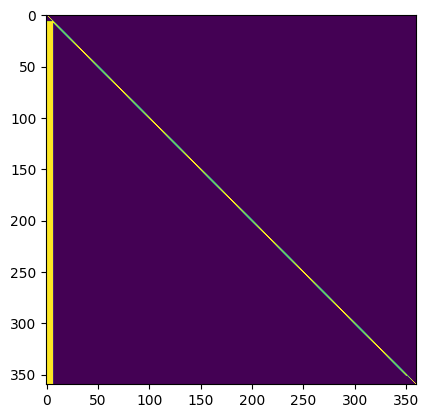

In [12]:
plt.imshow(base_mask_fn(nodes_ids[0], meta_data[0]))

In [13]:
with jax.default_device(cpu):
    data, nodes_ids, meta_data = sampler(jrandom.PRNGKey(0), 1000)

In [14]:


def time_embedding_builder(dim):
    dim1 = dim // 2
    dim2 = dim - dim1
    def f(t):
        embed1 = jnp.ones((dim1,))  * t
        embed2 = -jnp.ones((dim2,))  * t
        print(embed1.shape, embed2.shape)
        return jnp.concatenate([embed1 , embed2], axis=-1)
    return f

def transformer_model(num_nodes, dim = 250, condition_token_dim=50, num_heads=4, num_layers=8, attn_size=20, widening_factor=2, num_hidden_layers=2, output_scale_fn=None):
    
    if output_scale_fn is None:
        output_scale_fn = lambda t, x: x
    
    def model(t,data, data_id,meta_data, condition_mask, edge_mask=None):
        batch_size, current_nodes, _ = data.shape
        data_id = data_id.reshape(-1,current_nodes)
        condition_mask = condition_mask.reshape(-1,current_nodes)
        

        tokenizer = ScalarTokenizer(dim, num_nodes)
        time_embeder = GaussianFourierEmbedding(128)
        
        # Embedding
        tokens = tokenizer(data_id,data, meta_data)
        time = time_embeder(t[..., None])
        
        # Conditioning
        condition_token = hk.get_parameter("condition_token", shape=[1,1,condition_token_dim], init=hk.initializers.RandomNormal(0.01))
        condition_mask = condition_mask.reshape(-1,data.shape[-2],1)
        condition_token = condition_mask * condition_token
        condition_token = jnp.broadcast_to(condition_token, tokens.shape[:-1] + (condition_token_dim,))
        tokens = jnp.concatenate([tokens, condition_token], -1)
        
        
        # Forward pass 
        model = Transformer(num_heads=num_heads, num_layers=num_layers, attn_size=attn_size, widening_factor=widening_factor,num_hidden_layers=num_hidden_layers, skip_connection_attn=True)

        h = model(tokens, context=time, mask=edge_mask)
        out = hk.Linear(1)(h)
        out = output_scale_fn(t, out)
        return out
    
    init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
    return init_fn, model_fn

def init_sde_related(data, name="vpsde", **kwargs):
    # VPSDE 
    if name.lower() == "vpsde":
        p0 = Independent(Empirical(data), 1)
        beta_max = kwargs.get("beta_max",10.)
        beta_min = kwargs.get("beta_min", 0.01)
        sde = VPSDE(p0, beta_max=beta_max, beta_min=beta_min)
        T_max = kwargs.get("T_max", 1.)
        T_min = kwargs.get("T_min", 1e-5)

        # Train weight function
        def weight_fn(t):
            t = t.reshape(-1, 1, 1)
            return jnp.clip(1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) ,a_min = 1e-4)
        
        # Model output scale function
        def output_scale_fn(t, x):
            scale = jnp.sqrt(jnp.sum(sde.marginal_variance(t[..., None], x0=jnp.ones_like(x)), -1))
            return 1/scale[..., None] * x
        
    else:
        raise NotImplementedError()
    
    return sde, T_min, T_max, weight_fn, output_scale_fn

def run_train_conditional_score_model(key, params, opt_state, num_epochs, num_steps, batch_size,  update, sampler, print_every=100):
    num_devices = jax.device_count()
    batch_size_per_device = batch_size // num_devices
    batch_size = batch_size_per_device * num_devices
    
    # Replicated for multiple devices
    replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
    replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

    for j in range(num_epochs):
        l = 0
        for i in range(num_steps):
            key, key_batch1,key_batch2, key_update = jax.random.split(key, 4)
            #with jax.default_device(cpu):
            data_batch, node_id, node_metadata = sampler(key_batch1, batch_size)
            node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
            data_batch = data_batch.reshape((num_devices, batch_size_per_device, -1, 1))
            node_metadata_batch = node_metadata.reshape((num_devices, batch_size_per_device, -1, 1))
            loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id_batch, node_metadata_batch)
            l += loss[0] /num_steps
        if (j % print_every) == 0:     
            print("Train loss: ",l)
            
    params = jax.tree_map(lambda x: x[0], replicated_params)
    opt_state = jax.tree_map(lambda x: x[0], replicated_opt_state)
    
    return params, opt_state

class ACSE:
    def __init__(self, params, model_fn, sde, T_min=1e-5,T_max=1.) -> None:
        self.params = params
        self.model_fn = model_fn
        self.sde = sde

        self.T_min = T_min
        self.T_max = T_max
        self.marginal_end_std = jnp.squeeze(sde.marginal_stddev(jnp.array([T_max])))[None,...]
        self.marginal_end_mean = jnp.squeeze(sde.marginal_mean(jnp.array([T_max])))[None,...]
        
        self.node_id = None
        self.condition_mask = None
        self.meta_data = None
        
        
        
    def sample(self, key,num_samples, x_o, num_steps=500, node_id = None, condition_mask = None, meta_data=None, edge_mask=None, **kwargs):
        if node_id is None:
            node_id = self.node_id
        if condition_mask is None:
            condition_mask = self.condition_mask
        if meta_data is None:
            meta_data = self.meta_data
            
        assert node_id is not None, "node_id must be provided, or set as default"
        assert condition_mask is not None, "condition_mask must be provided, or set as default"
        
        key1, key2 = jax.random.split(key, 2)
        drift, diffusion = self._init_backward_sde(node_id, condition_mask, meta_data, edge_mask=edge_mask)
        # Fix this self.margin_end_std is of training length, not sampling length
        x_T = jax.random.normal(key1, (num_samples, node_id.shape[-1],)) #* self.marginal_end_std + self.marginal_end_mean
        condition_mask = condition_mask.reshape(x_T.shape[-1]).astype(bool)
        x_T = x_T.at[...,condition_mask].set(x_o.reshape(-1))
        keys = jax.random.split(key2, (num_samples,))
        ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal",**kwargs), in_axes= (0, None, None, 0, None), out_axes=0)(keys, drift, diffusion, x_T, jnp.linspace(0., self.T_max-self.T_min, num_steps))
        final_samples = ys[:, -1, ...][:,~condition_mask]
        final_samples = final_samples.reshape((num_samples, -1))
        return final_samples
        
    
    def log_prob(self, val, x_o, **kwargs):
        # Add backward ode to compute log_prob
        raise NotImplementedError()
    
    def set_default_node_id(self, node_id):
        self.node_id = node_id
    
    def set_default_condition_mask(self, condition_mask):
        self.condition_mask = condition_mask
        
    def set_default_meta_data(self, meta_data): 
        self.meta_data = meta_data

    
        
    def _init_backward_sde(self, node_id = None, condition_mask = None, meta_data=None, edge_mask=None, **kwargs):
        def drift_backward(t, x):
            t = (self.T_max-t)
            score = self.model_fn(self.params, jnp.atleast_1d(t), x.reshape(-1, x.shape[-1], 1), data_id = node_id.reshape(-1, x.shape[-1], 1), meta_data=meta_data.reshape(-1, x.shape[-1], 1),condition_mask=condition_mask.reshape(-1, x.shape[-1], 1), edge_mask=edge_mask).reshape(x.shape)
            drift = self.sde.drift(t, x)  - self.sde.diffusion(t, x)**2 * score
            return -drift.reshape(x.shape) * (1-condition_mask.reshape(x.shape))
        
        def diffusion_backward(t, x):
            t = (self.T_max-t)
            return self.sde.diffusion(t, x).reshape(x.shape) * (1-condition_mask.reshape(x.shape))
        
        return drift_backward, diffusion_backward
    

def mean_std_per_node_id(data, node_ids):
    node_ids = node_ids.reshape(-1)
    mean = []
    std = []
    for i in range(node_ids.max()+1):
        index = jnp.where(node_ids == i)
        mean.append(jnp.mean(data[:,index]))
        std.append(jnp.std(data[:,index]))
    mean, std=  jnp.stack(mean), jnp.clip(jnp.stack(std), a_min=1e-2, a_max=None)
    return mean, std
                 


In [15]:
with jax.default_device(cpu):
    data, node_ids, node_metadata = sampler(jax.random.PRNGKey(0), 10000)
    num_nodes = jnp.unique(node_ids).shape[0]
    
    mean_per_id, std_per_id = mean_std_per_node_id(data, node_ids)
    
    def z_score(data, node_ids, mean_per_id, std_per_id):
        data = (data - mean_per_id[node_ids])/std_per_id[node_ids]
        return data
    
    def de_z_score(data, node_ids, mean_per_id, std_per_id):
        data = data * std_per_id[node_ids] + mean_per_id[node_ids]
        return data
    
    z_score_fn = partial(z_score, mean_per_id=mean_per_id, std_per_id=std_per_id)
    de_z_score_fn = partial(de_z_score, mean_per_id=mean_per_id, std_per_id=std_per_id)
    
    def normed_sampler(key, batch_size):
        data, node_ids, node_metadata = sampler(key, batch_size)
        data = z_score_fn(data, node_ids)
        return data, node_ids, node_metadata
    

    sde, T_min,T_max, weight_fn, output_scale_fn = init_sde_related(z_score_fn(data, node_ids)[:,:num_nodes])

In [16]:
with jax.default_device(cpu):
    rng = jax.random.PRNGKey(0)
    data, node_ids, node_metadata = normed_sampler(jax.random.PRNGKey(0), 100)

In [17]:
with jax.default_device(cpu):
    init_fn, model_fn = transformer_model(num_nodes, output_scale_fn=output_scale_fn)
    rng, rng_init = jax.random.split(rng)
    params = init_fn(rng_init, jnp.ones((10,)) , data[:10], node_ids, node_metadata[:10], jnp.zeros_like(data[:10]))

In [18]:
with jax.default_device(cpu):
    num_epochs = 100
    batch_size = 1000
    #num_steps = thetas.shape[0] // batch_size
    num_steps=100
    print_every = num_epochs // 20
    total_number_steps = num_epochs * num_steps

    learning_rate = 5e-4
    scheduler = optax.linear_schedule(init_value=learning_rate, end_value=0, transition_steps=total_number_steps//2, transition_begin=total_number_steps//2)
    optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(scheduler))

In [19]:
max_num_nodes = node_ids.shape[-2]
base_mask = base_mask_fn(nodes_ids, meta_data)
def loss_fn(params, key, data, node_id, meta_data):
    key_times, key_loss, key_condition = jax.random.split(key,3)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    
    key_choice, key_prob, key_bernoulli = jax.random.split(key_condition,3)
    

    # Randomly choose to condition on a few nodes
    condition_mask = jax.random.choice(key_choice, jnp.array([[0]*max_num_nodes, [1]*7 + [0]*(max_num_nodes-7),[0]*7 + [1]*(max_num_nodes-15) + [0]*8,[0]*7 + [0]*(max_num_nodes-15) + [1]*8, jrandom.bernoulli(key_prob, 0.3, shape=(max_num_nodes,)).astype(int),jrandom.bernoulli(key_bernoulli, 0.7, shape=(max_num_nodes,)).astype(int)]), shape=(data.shape[0], ), axis=0)
    edge_mask = jax.vmap(min_faithfull_mask, in_axes=(None, 0))(base_mask, condition_mask)
    
    
    loss = denoising_score_matching_loss(params, key_loss, times, data, loss_mask=condition_mask, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn, data_id=node_id, condition_mask=condition_mask, meta_data=meta_data, edge_mask = edge_mask)
    return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id, meta_data):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id, meta_data)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [95]:
params = jnp.load("hh_model3.npy", allow_pickle=True).item()

In [96]:
with jax.default_device(cpu): # Data management on CPU, updates lauched on GPUs
    rng, rng_train = jax.random.split(rng)
    opt_state = optimizer.init(params)
    params, opt_state = run_train_conditional_score_model(rng_train, params, opt_state, num_epochs, num_steps, batch_size, update, normed_sampler, print_every=print_every)

Train loss:  32.208427
Train loss:  26.409266
Train loss:  27.876322
Train loss:  30.102188
Train loss:  32.32064
Train loss:  27.20497
Train loss:  28.050842
Train loss:  28.32548
Train loss:  23.439629
Train loss:  30.979685
Train loss:  26.958475
Train loss:  26.990343
Train loss:  20.261639
Train loss:  22.38953
Train loss:  27.655827
Train loss:  22.219618
Train loss:  25.230783
Train loss:  26.6914
Train loss:  20.76404
Train loss:  21.319965


In [98]:
jnp.save("hh_model3.npy", params)

In [134]:
eval_num_timepoints = 300
eval_num_nodes = 7 + eval_num_timepoints + 8
node_ids = jnp.array([0, 1, 2, 3,4,5,6] + [7] * eval_num_timepoints + [8] + [9,10,11,12,13,14,15])
node_metadata = jnp.array([jnp.nan]*7 + list(jnp.linspace(t_min, t_max, eval_num_timepoints)) + [jnp.nan]*8) # Time points
condition_mask = jnp.array([0]*eval_num_nodes, dtype=bool)


In [135]:
model = ACSE(params, model_fn, sde, T_min, T_max)

In [136]:
model.set_default_node_id(node_ids)
model.set_default_meta_data(node_metadata)

In [137]:
likelihood_condtion_mask = jnp.array([1] * 7 +  [0]  * (eval_num_nodes-7), dtype=bool)
eval_base_mask = base_mask_fn(node_ids, node_metadata)
edge_mask = min_faithfull_mask(eval_base_mask, likelihood_condtion_mask)
theta_star = data[5,:7]

In [138]:
with jax.default_device(jax.devices()[0]):
    samples = model.sample(jrandom.PRNGKey(1), 1, theta_star, num_steps=800, condition_mask=likelihood_condtion_mask, edge_mask=edge_mask)

In [139]:
V, energy, summary_stats = jnp.split(de_z_score(samples.reshape(1, -1, 1), node_ids.reshape(1,-1,1)[:, 7:,:], mean_per_id, std_per_id).flatten(), (eval_num_timepoints, eval_num_timepoints + 1,), axis=-1)

In [140]:
energy

Array([-0.796], dtype=float32)

In [141]:
summary_stats

Array([  12.926,  -65.127,    0.345,  -52.961, 1030.874,    2.376,
          7.346], dtype=float32)

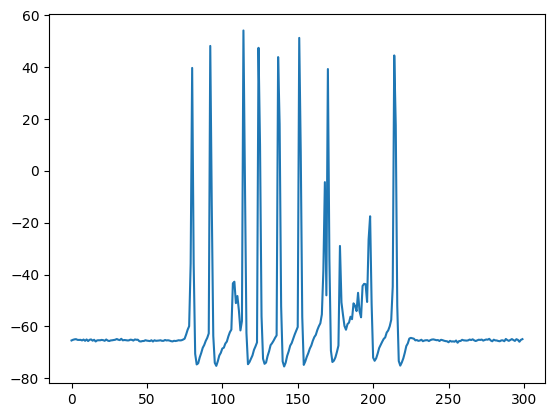

In [142]:
_ = plt.plot(V.T)

In [151]:
model2 = ACSE(params, model_fn, sde, T_min, T_max)
posterior_condtion_mask = jnp.array([0] * 7 +  [1]  * num_timeponts , dtype=jnp.bool_)
node_ids_posterior = jnp.array([0, 1, 2, 3,4,5,6] + [7] * num_timeponts )
posterior_base_mask1 = base_mask[:-8,:-8]
edge_mask_posterior = min_faithfull_mask(posterior_base_mask1, posterior_condtion_mask)
meta_data_posterior = jax.device_put(meta_data[6,:-8,0], jax.devices()[0])
x_o = jax.device_put(data[6,7:-8,0], jax.devices()[0])

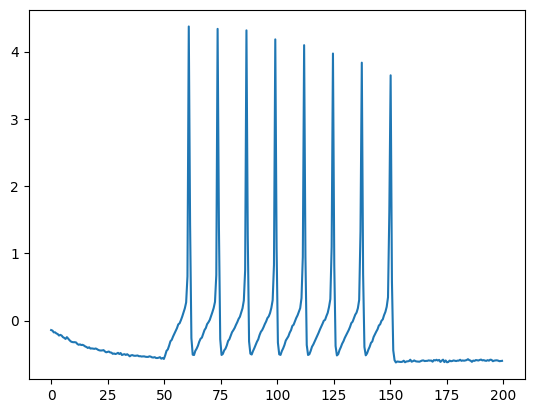

In [152]:
plt.plot(meta_data_posterior[7:],x_o)

In [153]:
model2.set_default_node_id(node_ids_posterior)
model2.set_default_meta_data(meta_data_posterior)
model2.set_default_condition_mask(posterior_condtion_mask)

In [154]:
all_samples = []

for i in range(5):
    samples = model2.sample(jrandom.PRNGKey(i), 1000, x_o, num_steps=400, edge_mask=edge_mask_posterior)
    samples = jax.device_put(samples, cpu)
    all_samples.append(samples)
    del samples

: 

In [ ]:
all_samples = jnp.concatenate(all_samples, axis=0)

In [ ]:
from sbi.analysis import pairplot  
import numpy as np

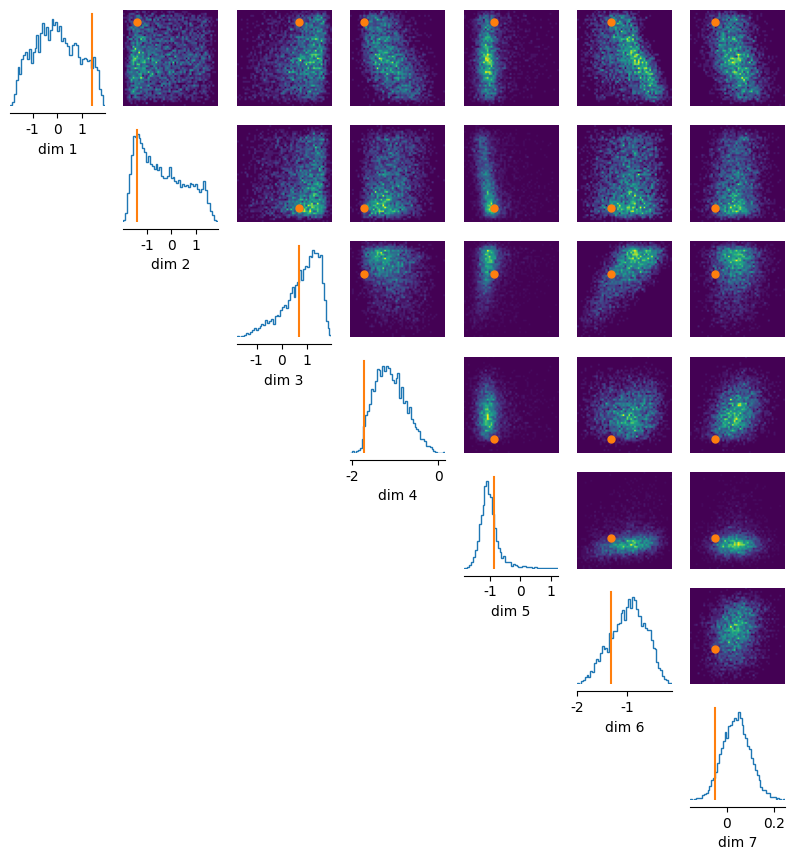

In [ ]:
_ = pairplot(np.array(all_samples.reshape(5000, 7)), points=np.array(data[6, :7, 0]))

In [147]:
model3 = ACSE(params, model_fn, sde, T_min, T_max)
posterior_condtion_mask = jnp.array([0] * 7 + [1]*7, dtype=bool)
node_ids_posterior = jnp.array([0, 1, 2, 3,4,5,6] + [9,10,11,12,13,14,15])
theta_mask = jnp.eye(7, dtype=jnp.bool_)
theta_x_mask = jnp.ones((7,7), dtype=jnp.bool_)
theta_x_fill = jnp.zeros((7,7), dtype=jnp.bool_)
x_mask = jnp.eye(7, dtype=jnp.bool_)
base_mask_posterior2 = jnp.block([[theta_mask, theta_x_fill],[theta_x_mask, x_mask]])
edge_mask_posterior2 = min_faithfull_mask(base_mask_posterior2, posterior_condtion_mask)
meta_data_posterior = jax.device_put(jnp.concatenate([meta_data[6,:7,0], meta_data[6, -7:,0]]), jax.devices()[0])
x_o = jax.device_put(data[6,-7:,0], jax.devices()[0])


In [148]:
model3.set_default_node_id(node_ids_posterior)
model3.set_default_meta_data(meta_data_posterior)
model3.set_default_condition_mask(posterior_condtion_mask)

In [149]:
samples = model3.sample(jrandom.PRNGKey(1), 5000, x_o, num_steps=400, edge_mask=edge_mask_posterior2)

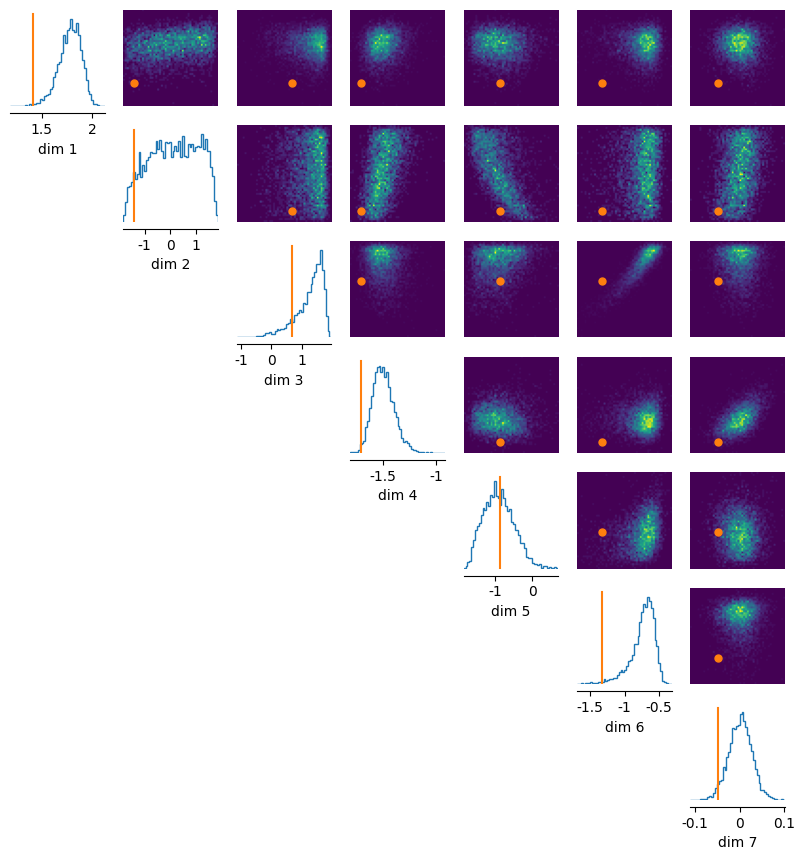

In [150]:
_ = pairplot(np.array(samples), points=np.array(data[6, :7, 0]))